# Loan Default Prediction — Final Project
## Fundamentals of Data Science

**Dataset:** Give Me Some Credit — Kaggle  
**Source:** https://www.kaggle.com/c/GiveMeSomeCredit  
**Target Variable:** `SeriousDelinquency` — Whether a borrower will experience financial distress within 2 years (1 = Default, 0 = No Default)

---
### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Data Collection |
| 2 | Data Tidying & Cleaning |
| 3 | Feature Extraction |
| 4 | Feature Selection |
| 5 | Data Imbalance Handling + Modeling + Evaluation |
| 5A | Approach 1 — SMOTE Only |
| 5B | Approach 2 — Class Weights Only |
| 5C | Full Comparison & Best Model Selection |
| 6 | Data Visualization (Bonus) |
---

---
# Step 1 — Data Collection

**Dataset:** Give Me Some Credit  
**Source URL:** https://www.kaggle.com/c/GiveMeSomeCredit/data  
**File Used:** `cs-training.csv`  
**Size:** ~150,000 rows × 11 columns  

**Features:**
| Feature | Description |
|---------|-------------|
| RevolvingUtilizationRate | Ratio of credit used vs total limit (0–1) |
| Age | Borrower age in years |
| Late30to59Days | Times 30–59 days past due in last 2 years |
| DebtRatio | Monthly debt / monthly income |
| MonthlyIncome | Monthly income in USD |
| OpenCreditLines | Number of open credit lines |
| Times90DaysLate | Times 90+ days past due |
| RealEstateLoans | Number of real estate loans |
| Late60to89Days | Times 60–89 days past due |
| NumberOfDependents | Number of financial dependents |
| **SeriousDelinquency** | **Target: 1 = defaulted, 0 = did not default** |

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('Libraries imported successfully')

Libraries imported successfully


In [17]:
df = pd.read_csv(r'cs-training.csv', index_col=0)

df.columns = [
    'SeriousDelinquency',
    'RevolvingUtilizationRate',
    'Age',
    'Late30to59Days',
    'DebtRatio',
    'MonthlyIncome',
    'OpenCreditLines',
    'Times90DaysLate',
    'RealEstateLoans',
    'Late60to89Days',
    'NumberOfDependents'
]

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumn types:')
print(df.dtypes)
df.head()

Dataset loaded: 150,000 rows x 11 columns

Column types:
SeriousDelinquency            int64
RevolvingUtilizationRate    float64
Age                           int64
Late30to59Days                int64
DebtRatio                   float64
MonthlyIncome               float64
OpenCreditLines               int64
Times90DaysLate               int64
RealEstateLoans               int64
Late60to89Days                int64
NumberOfDependents          float64
dtype: object


,SeriousDelinquency,RevolvingUtilizationRate,Age,Late30to59Days,DebtRatio,MonthlyIncome,OpenCreditLines,Times90DaysLate,RealEstateLoans,Late60to89Days,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [18]:
df_original = df.copy()
print(f'Original dataset saved: {df_original.shape[0]:,} rows x {df_original.shape[1]} columns')
print('df_original will be used for before/after comparisons throughout the notebook')

Original dataset saved: 150,000 rows x 11 columns
df_original will be used for before/after comparisons throughout the notebook


---
# Step 2 — Data Tidying & Data Cleaning

**Cleaning decisions:**
- `SeriousDelinquency`: converted float → int (binary target)
- `Age = 0`: biologically impossible → replaced with NaN and imputed with median
- Sentinel codes `96` and `98` in late-payment columns: known Kaggle encoding errors → replaced with NaN
- `MonthlyIncome` (19.8% missing): median imputation — distribution is right-skewed, median is more robust
- `NumberOfDependents` (2.6% missing): mode imputation — discrete count variable
- `RevolvingUtilizationRate`: capped at 1.0 — values above 1 indicate data entry errors
- `MonthlyIncome` and `DebtRatio`: Winsorized at 99th percentile — preserves rows while reducing extreme influence
- Duplicates removed to prevent model bias

In [19]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Target Variable Distribution ===')
counts = df['SeriousDelinquency'].value_counts()
pct    = df['SeriousDelinquency'].value_counts(normalize=True) * 100
dist   = pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(2)})
dist.index = ['No Default (0)', 'Default (1)']
print(dist)

print('\n=== Descriptive Statistics ===')
display(df.describe())

=== Dataset Shape ===
Rows: 150,000  |  Columns: 11

=== Target Variable Distribution ===
                 Count  Percentage (%)
No Default (0)  139974         93.3200
Default (1)      10026          6.6800

=== Descriptive Statistics ===


,SeriousDelinquency,RevolvingUtilizationRate,Age,Late30to59Days,DebtRatio,MonthlyIncome,OpenCreditLines,Times90DaysLate,RealEstateLoans,Late60to89Days,NumberOfDependents
count,150000.0000,150000.0000,150000.0000,150000.0000,150000.0000,120269.0000,150000.0000,150000.0000,150000.0000,150000.0000,146076.0000
mean,0.0668,6.0484,52.2952,0.4210,353.0051,6670.2212,8.4528,0.2660,1.0182,0.2404,0.7572
std,0.2497,249.7554,14.7719,4.1928,2037.8185,14384.6742,5.1460,4.1693,1.1298,4.1552,1.1151
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0299,41.0000,0.0000,0.1751,3400.0000,5.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.1542,52.0000,0.0000,0.3665,5400.0000,8.0000,0.0000,1.0000,0.0000,0.0000
75%,0.0000,0.5590,63.0000,0.0000,0.8683,8249.0000,11.0000,0.0000,2.0000,0.0000,1.0000
max,1.0000,50708.0000,109.0000,98.0000,329664.0000,3008750.0000,58.0000,98.0000,54.0000,98.0000,20.0000


In [20]:
num_duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {num_duplicates}')
if num_duplicates > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f'Duplicates removed. New shape: {df.shape}')

Duplicate rows found: 609
Duplicates removed. New shape: (149391, 11)


In [21]:
before_missing = df.isnull().sum()
before_max     = df.describe().loc['max']
print('=== Missing Values BEFORE Cleaning ===')
print(before_missing[before_missing > 0])
print(f'\nTotal missing: {before_missing.sum():,}')

=== Missing Values BEFORE Cleaning ===
MonthlyIncome         29221
NumberOfDependents     3828
dtype: int64

Total missing: 33,049


In [22]:
df['SeriousDelinquency'] = df['SeriousDelinquency'].astype(int)

age_zero = (df['Age'] == 0).sum()
print(f'Age = 0 entries: {age_zero} → replaced with NaN')
df.loc[df['Age'] == 0, 'Age'] = np.nan

late_cols = ['Late30to59Days', 'Times90DaysLate', 'Late60to89Days']
for col in late_cols:
    sentinel_count = df[col].isin([96, 98]).sum()
    if sentinel_count > 0:
        print(f'Sentinel values in {col}: {sentinel_count} → replaced with NaN')
        df[col] = df[col].replace([96, 98], np.nan)

Age = 0 entries: 1 → replaced with NaN
Sentinel values in Late30to59Days: 225 → replaced with NaN
Sentinel values in Times90DaysLate: 225 → replaced with NaN
Sentinel values in Late60to89Days: 225 → replaced with NaN


=== Missing Value Summary ===
                    Missing Count  Missing %
MonthlyIncome               29221    19.5600
NumberOfDependents           3828     2.5600
Late30to59Days                225     0.1500
Times90DaysLate               225     0.1500
Late60to89Days                225     0.1500
Age                             1     0.0000


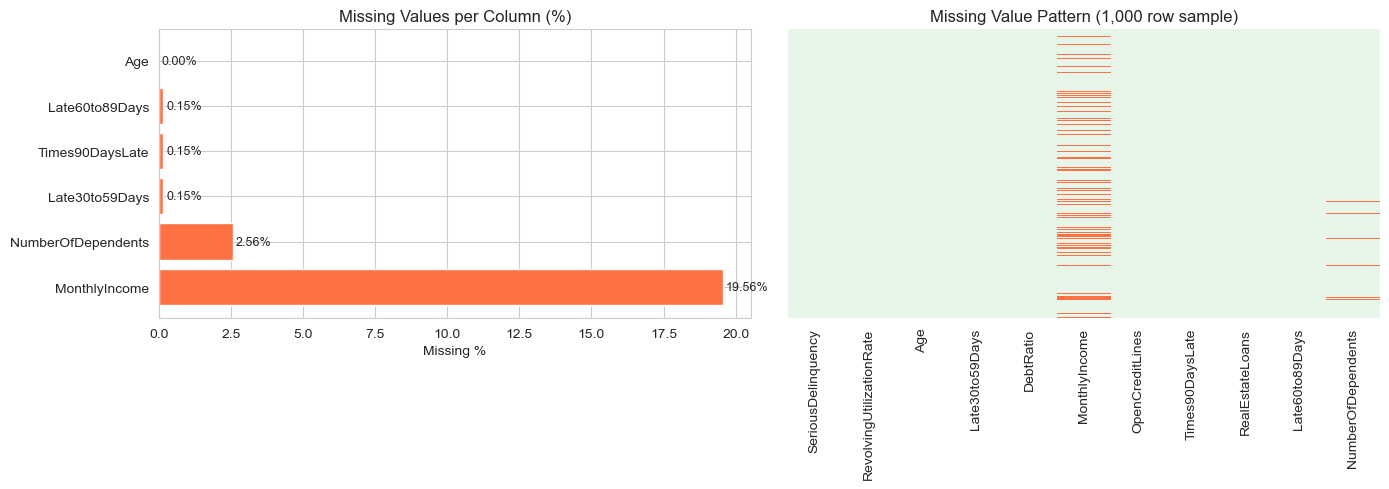

In [23]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('=== Missing Value Summary ===')
print(missing_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(missing_df.index, missing_df['Missing %'], color='#FF7043', edgecolor='white')
for i, (col, row) in enumerate(missing_df.iterrows()):
    axes[0].text(row['Missing %'] + 0.1, i, f"{row['Missing %']:.2f}%", va='center', fontsize=9)
axes[0].set_title('Missing Values per Column (%)')
axes[0].set_xlabel('Missing %')

sample = df.sample(1000, random_state=42)
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap=['#E8F5E9', '#FF7043'], ax=axes[1])
axes[1].set_title('Missing Value Pattern (1,000 row sample)')
plt.tight_layout()

plt.show()

In [24]:
def winsorize_col(df, col, upper_pct=0.99):
    cap    = df[col].quantile(upper_pct)
    before = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    print(f'  {col}: capped at {cap:,.2f} — {before} values modified')
    return df

print('=== Outlier Treatment (Winsorization at 99th percentile) ===')
df = winsorize_col(df, 'MonthlyIncome', 0.99)
df = winsorize_col(df, 'DebtRatio', 0.99)

above_one = (df['RevolvingUtilizationRate'] > 1).sum()
df['RevolvingUtilizationRate'] = df['RevolvingUtilizationRate'].clip(upper=1.0)
print(f'  RevolvingUtilizationRate: capped at 1.0 — {above_one} values modified')

=== Outlier Treatment (Winsorization at 99th percentile) ===
  MonthlyIncome: capped at 25,000.00 — 1168 values modified
  DebtRatio: capped at 4,985.10 — 1494 values modified
  RevolvingUtilizationRate: capped at 1.0 — 3321 values modified


In [25]:
income_median   = df['MonthlyIncome'].median()
dependents_mode = df['NumberOfDependents'].mode()[0]
age_median      = df['Age'].median()

df['MonthlyIncome']       = df['MonthlyIncome'].fillna(income_median)
df['NumberOfDependents']  = df['NumberOfDependents'].fillna(dependents_mode)
df['Age']                 = df['Age'].fillna(age_median)

for col in late_cols:
    df[col] = df[col].fillna(df[col].median())

df['NumberOfDependents'] = df['NumberOfDependents'].astype(int)
df['Age']                = df['Age'].astype(int)

print('=== Imputation Summary ===')
print(f'  MonthlyIncome      → MEDIAN = {income_median:,.2f}')
print(f'  NumberOfDependents → MODE   = {dependents_mode}')
print(f'  Age                → MEDIAN = {age_median}')
print(f'  Late columns       → MEDIAN (per column)')
print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

=== Imputation Summary ===
  MonthlyIncome      → MEDIAN = 5,400.00
  NumberOfDependents → MODE   = 0.0
  Age                → MEDIAN = 52.0
  Late columns       → MEDIAN (per column)

Missing values remaining: 0


In [26]:
print('=' * 65)
print('           CLEANING REPORT — BEFORE vs AFTER')
print('=' * 65)

after_missing = df.isnull().sum()
missing_report = pd.DataFrame({
    'Missing BEFORE': before_missing,
    'Missing AFTER' : after_missing,
    'Fixed?'        : before_missing.map(lambda x: '[FIXED]' if x > 0 else 'N/A')
})
missing_report = missing_report[before_missing > 0]
print('\n--- Missing Values ---')
print(missing_report)
print(f'\nTotal missing before : {before_missing.sum():,}')
print(f'Total missing after  : {after_missing.sum():,}')
assert after_missing.sum() == 0, ' Still has missing values!'
print(' No missing values remaining')

after_max = df.describe().loc['max']
outlier_cols = ['MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationRate']
print('\n--- Outlier Treatment (Max Values Before vs After) ---')
for col in outlier_cols:
    b = df_original[col].max()
    a = df[col].max()
    changed = ' capped' if b != a else '— unchanged'
    print(f'  {col:30s}: {b:>15,.2f}  →  {a:>15,.2f}  {changed}')

print('\n--- Shape ---')
print(f'  Original : {df_original.shape[0]:,} rows x {df_original.shape[1]} cols')
print(f'  Cleaned  : {df.shape[0]:,} rows x {df.shape[1]} cols')
removed = df_original.shape[0] - df.shape[0]
print(f'  Rows removed (duplicates): {removed:,}')

           CLEANING REPORT — BEFORE vs AFTER

--- Missing Values ---
                    Missing BEFORE  Missing AFTER   Fixed?
MonthlyIncome                29221              0  [FIXED]
NumberOfDependents            3828              0  [FIXED]

Total missing before : 33,049
Total missing after  : 0
 No missing values remaining

--- Outlier Treatment (Max Values Before vs After) ---
  MonthlyIncome                 :    3,008,750.00  →        25,000.00   capped
  DebtRatio                     :      329,664.00  →         4,985.10   capped
  RevolvingUtilizationRate      :       50,708.00  →             1.00   capped

--- Shape ---
  Original : 150,000 rows x 11 cols
  Cleaned  : 149,391 rows x 11 cols
  Rows removed (duplicates): 609


In [27]:
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

df['IncomeBracket'] = pd.cut(df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000, float('inf')],
    labels=['<3K', '3K-6K', '6K-10K', '10K-20K', '>20K'])

pivot1 = df.pivot_table(
    values='SeriousDelinquency', index='AgeGroup',
    aggfunc=['mean', 'count', 'sum']
)
pivot1.columns = ['Default Rate', 'Total Borrowers', 'Total Defaults']
pivot1['Default Rate (%)'] = (pivot1['Default Rate'] * 100).round(2)

print('=== Pivot Table 1: Default Rate by Age Group ===')
print(pivot1[['Total Borrowers', 'Total Defaults', 'Default Rate (%)']])

pivot2 = df.pivot_table(
    values='SeriousDelinquency', index='IncomeBracket',
    aggfunc=['mean', 'count']
)
pivot2.columns = ['Default Rate', 'Total Borrowers']
pivot2['Default Rate (%)'] = (pivot2['Default Rate'] * 100).round(2)

print('\n=== Pivot Table 2: Default Rate by Income Bracket ===')
print(pivot2[['Total Borrowers', 'Default Rate (%)']])

pivot3 = df.pivot_table(
    values=['MonthlyIncome', 'DebtRatio'],
    index='AgeGroup', columns='SeriousDelinquency', aggfunc='median'
)
print('\n=== Pivot Table 3: Median Income & Debt Ratio by Age Group × Default Status ===')
print(pivot3.round(2))

df.drop(columns=['AgeGroup', 'IncomeBracket'], inplace=True)

=== Pivot Table 1: Default Rate by Age Group ===
          Total Borrowers  Total Defaults  Default Rate (%)
AgeGroup                                                   
<25                  2843             330           11.6100
25-35               18408            2050           11.1400
35-45               29773            2626            8.8200
45-55               36641            2783            7.6000
55-65               33319            1530            4.5900
65+                 28407             690            2.4300

=== Pivot Table 2: Default Rate by Income Bracket ===
               Total Borrowers  Default Rate (%)
IncomeBracket                                   
<3K                      23371            9.4600
3K-6K                    73209            6.9800
6K-10K                   32876            5.5800
10K-20K                  16216            4.1900
>20K                      2103            5.3300

=== Pivot Table 3: Median Income & Debt Ratio by Age Group × Default Sta

---
# Step 3 — Feature Extraction

We derive new features that capture behavioral patterns not directly observable in raw columns:

| New Feature | Formula | Rationale |
|------------|---------|----------|
| `TotalLatePayments` | sum of all 3 late columns | Aggregates the borrower's full late-payment history into a single risk signal |
| `IncomePerDependent` | MonthlyIncome / (Dependents + 1) | Measures disposable income pressure; more dependents on lower income = higher risk |
| `DebtBurden` | DebtRatio × MonthlyIncome | Converts the ratio into an absolute monthly debt figure, which is more interpretable |
| `CreditRiskScore` | RevolvingUtilizationRate × TotalLatePayments | Combines utilization and payment behavior into one compound risk proxy |
| `AgeGroup_encoded` | Binned age → integer | Captures non-linear age effects (young borrowers tend to have higher default rates) |

In [28]:
df['TotalLatePayments'] = (
    df['Late30to59Days'] +
    df['Late60to89Days'] +
    df['Times90DaysLate']
)

df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

df['DebtBurden'] = df['DebtRatio'] * df['MonthlyIncome']

df['CreditRiskScore'] = df['RevolvingUtilizationRate'] * (df['TotalLatePayments'] + 1)

age_bins   = [0, 25, 35, 45, 55, 65, 120]
age_labels = [0, 1, 2, 3, 4, 5]
df['AgeGroup_encoded'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels).astype(int)

new_features = ['TotalLatePayments', 'IncomePerDependent', 'DebtBurden',
                'CreditRiskScore', 'AgeGroup_encoded']

print('=== New Features — Descriptive Statistics ===')
print(df[new_features].describe().round(3))

print('\n=== Correlation of New Features with Target ===')
for feat in new_features:
    corr = df[feat].corr(df['SeriousDelinquency'])
    print(f'  {feat:25s}: {corr:.4f}')

=== New Features — Descriptive Statistics ===
       TotalLatePayments  IncomePerDependent    DebtBurden  CreditRiskScore  \
count        149391.0000         149391.0000   149391.0000      149391.0000   
mean              0.4020           4432.8100  1617195.1470           0.5680   
std               1.1030           3234.9280  4793014.7340           1.0860   
min               0.0000              0.0000        0.0000           0.0000   
25%               0.0000           2150.0000      787.8250           0.0320   
50%               0.0000           4000.0000     2113.6690           0.1700   
75%               0.0000           5400.0000     4801.4870           0.6770   
max              19.0000          25000.0000 26919540.0000          20.0000   

       AgeGroup_encoded  
count       149391.0000  
mean             3.1010  
std              1.3550  
min              0.0000  
25%              2.0000  
50%              3.0000  
75%              4.0000  
max              5.0000  

=== Cor

---
# Step 4 — Feature Selection

Two methods are applied and their selections are compared:

**Method 1 — SelectKBest (ANOVA F-test):** Statistical univariate test that ranks each feature independently by its F-score against the target. Fast and transparent but ignores feature interactions.

**Method 2 — RFE with Random Forest:** Recursive Feature Elimination uses a model to iteratively remove the least important feature. Captures non-linear relationships and interactions but is more computationally expensive.

Features selected by both methods are the most reliable candidates for modeling.

In [29]:
ALL_FEATURES = [
    'RevolvingUtilizationRate', 'Age', 'Late30to59Days', 'DebtRatio',
    'MonthlyIncome', 'OpenCreditLines', 'Times90DaysLate', 'RealEstateLoans',
    'Late60to89Days', 'NumberOfDependents',
    'TotalLatePayments', 'IncomePerDependent', 'DebtBurden',
    'CreditRiskScore', 'AgeGroup_encoded'
]
TARGET_COL = 'SeriousDelinquency'
K = 10

X_all = df[ALL_FEATURES]
y     = df[TARGET_COL]

selector_kbest = SelectKBest(score_func=f_classif, k=K)
selector_kbest.fit(X_all, y)

kbest_scores   = pd.Series(selector_kbest.scores_, index=ALL_FEATURES).sort_values(ascending=False)
kbest_selected = list(kbest_scores.head(K).index)

print('=== Method 1: SelectKBest (ANOVA F-test) ===')
print(kbest_scores.round(2).to_string())
print(f'\nTop {K} selected: {kbest_selected}')

=== Method 1: SelectKBest (ANOVA F-test) ===
CreditRiskScore            30527.7700
TotalLatePayments          26620.8800
Times90DaysLate            16102.7100
RevolvingUtilizationRate   12641.1600
Late30to59Days             11888.9600
Late60to89Days             11350.9100
Age                         2028.0700
AgeGroup_encoded            1995.3800
IncomePerDependent           565.2800
MonthlyIncome                364.2100
NumberOfDependents           324.2400
OpenCreditLines              139.4200
DebtRatio                     46.6200
DebtBurden                    41.9000
RealEstateLoans                8.7000

Top 10 selected: ['CreditRiskScore', 'TotalLatePayments', 'Times90DaysLate', 'RevolvingUtilizationRate', 'Late30to59Days', 'Late60to89Days', 'Age', 'AgeGroup_encoded', 'IncomePerDependent', 'MonthlyIncome']


In [30]:
rfe_estimator = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rfe_selector  = RFE(estimator=rfe_estimator, n_features_to_select=K, step=1)
rfe_selector.fit(X_all, y)

rfe_ranking  = pd.Series(rfe_selector.ranking_, index=ALL_FEATURES).sort_values()
rfe_selected = list(rfe_ranking[rfe_ranking == 1].index)

print('=== Method 2: RFE with Random Forest ===')
print(rfe_ranking.to_string())
print(f'\nTop {K} selected: {rfe_selected}')

=== Method 2: RFE with Random Forest ===
RevolvingUtilizationRate    1
Age                         1
Late30to59Days              1
DebtRatio                   1
OpenCreditLines             1
Times90DaysLate             1
Late60to89Days              1
TotalLatePayments           1
CreditRiskScore             1
AgeGroup_encoded            1
IncomePerDependent          2
MonthlyIncome               3
DebtBurden                  4
RealEstateLoans             5
NumberOfDependents          6

Top 10 selected: ['RevolvingUtilizationRate', 'Age', 'Late30to59Days', 'DebtRatio', 'OpenCreditLines', 'Times90DaysLate', 'Late60to89Days', 'TotalLatePayments', 'CreditRiskScore', 'AgeGroup_encoded']


=== Feature Selection Comparison ===
Selected by BOTH methods (8): ['Age', 'AgeGroup_encoded', 'CreditRiskScore', 'Late30to59Days', 'Late60to89Days', 'RevolvingUtilizationRate', 'Times90DaysLate', 'TotalLatePayments']
Only by SelectKBest  (2): ['IncomePerDependent', 'MonthlyIncome']
Only by RFE          (2): ['DebtRatio', 'OpenCreditLines']

Final features used for modeling (8): ['Age', 'AgeGroup_encoded', 'CreditRiskScore', 'Late30to59Days', 'Late60to89Days', 'RevolvingUtilizationRate', 'Times90DaysLate', 'TotalLatePayments']


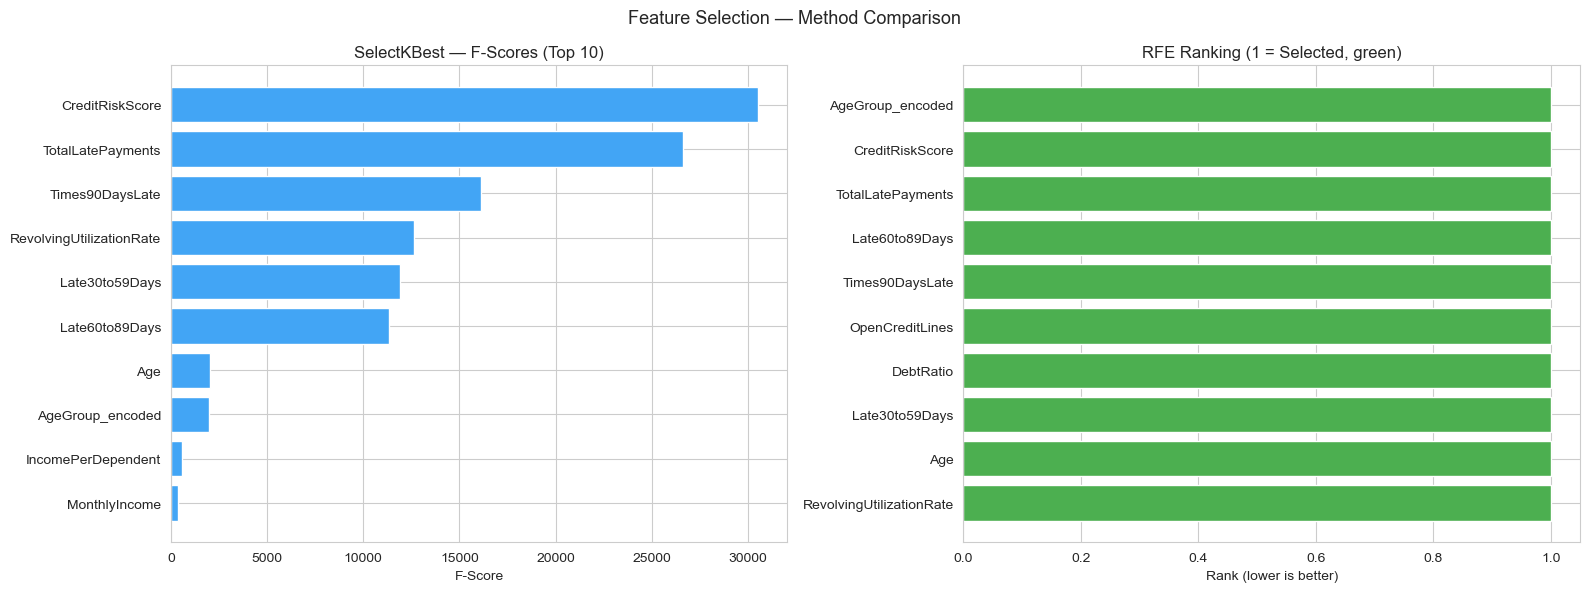

In [31]:
common_features = list(set(kbest_selected) & set(rfe_selected))
only_kbest      = list(set(kbest_selected) - set(rfe_selected))
only_rfe        = list(set(rfe_selected)   - set(kbest_selected))

print('=== Feature Selection Comparison ===')
print(f'Selected by BOTH methods ({len(common_features)}): {sorted(common_features)}')
print(f'Only by SelectKBest  ({len(only_kbest)}): {sorted(only_kbest)}')
print(f'Only by RFE          ({len(only_rfe)}): {sorted(only_rfe)}')

FINAL_FEATURES = common_features if len(common_features) >= 6 else kbest_selected
print(f'\nFinal features used for modeling ({len(FINAL_FEATURES)}): {sorted(FINAL_FEATURES)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_kbest = kbest_scores.head(10).sort_values()
axes[0].barh(top10_kbest.index, top10_kbest.values, color='#42A5F5', edgecolor='white')
axes[0].set_title('SelectKBest — F-Scores (Top 10)')
axes[0].set_xlabel('F-Score')

top10_rfe = rfe_ranking.head(10).sort_values(ascending=False)
colors    = ['#4CAF50' if r == 1 else '#EF5350' for r in top10_rfe.values]
axes[1].barh(top10_rfe.index, top10_rfe.values, color=colors, edgecolor='white')
axes[1].set_title('RFE Ranking (1 = Selected, green)')
axes[1].set_xlabel('Rank (lower is better)')

plt.suptitle('Feature Selection — Method Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---
# Step 5 — Data Imbalance Handling + Modeling + Evaluation

**Class Imbalance:** The dataset is heavily imbalanced (~6.7% defaults vs ~93.3% non-defaults).

**Two strategies are compared side by side:**

| | Approach 1 — SMOTE | Approach 2 — Class Weights |
|---|---|---|
| **Idea** | Generate synthetic minority samples to balance the dataset | Tell the model to penalize mistakes on the minority class more |
| **Effect on data size** | Training set grows | Training set stays the same |
| **How it works** | Oversamples class 1 until 50/50 | Assigns higher loss weight to class 1 |
| **Risk** | May overfit on synthetic samples | No data added, less overfitting risk |

**Models trained:** Random Forest and XGBoost — under each approach independently.  
**Threshold tuning:** Best threshold selected by maximizing F1-score on the Precision-Recall curve.

In [ ]:
print('=== Data Source Verification Before Modeling ===')
print(f'df shape            : {df.shape}')
print(f'Missing values in df: {df.isnull().sum().sum()}')
assert df.isnull().sum().sum() == 0, '[ERROR] df has missing values — check cleaning steps!'

original_max_income = df_original['MonthlyIncome'].max()
clean_max_income    = df['MonthlyIncome'].max()
assert original_max_income != clean_max_income, '️  MonthlyIncome unchanged — Winsorization may not have run'

print(f'[OK] df is clean and ready for modeling')
print(f'[OK] Confirmed: using cleaned df (MonthlyIncome max: {clean_max_income:,.0f} vs original: {original_max_income:,.0f})')

=== Data Source Verification Before Modeling ===
df shape            : (149391, 16)
Missing values in df: 0
[OK] df is clean and ready for modeling
[OK] Confirmed: using cleaned df (MonthlyIncome max: 25,000 vs original: 3,008,750)


In [33]:
X = df[FINAL_FEATURES]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Train / Test Split ===')
print(f'  Training samples : {X_train.shape[0]:,}')
print(f'  Test samples     : {X_test.shape[0]:,}')

print('\n=== Class Distribution in Training Set (Original) ===')
before = y_train.value_counts()
print(f'  No Default (0): {before[0]:,}  ({before[0]/len(y_train)*100:.1f}%)')
print(f'  Default    (1): {before[1]:,}  ({before[1]/len(y_train)*100:.1f}%)')
print(f'  Ratio: {before[0]/before[1]:.1f} : 1')
print('\nTest set is NEVER touched by any balancing technique (reflects real-world distribution)')

=== Train / Test Split ===
  Training samples : 119,512
  Test samples     : 29,879

=== Class Distribution in Training Set (Original) ===
  No Default (0): 111,505  (93.3%)
  Default    (1): 8,007  (6.7%)
  Ratio: 13.9 : 1

Test set is NEVER touched by any balancing technique (reflects real-world distribution)


---
## 5A — Approach 1: SMOTE Only

**SMOTE** (Synthetic Minority Over-sampling Technique) creates new synthetic samples for the minority class by interpolating between existing minority samples.

> ️ SMOTE is applied **only on the training set** after the split.  
> Applying it before splitting would cause **data leakage** (synthetic samples derived from test records contaminate training).

**Models in this approach use NO class weights** — the balancing is handled entirely by SMOTE.

In [34]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE as SMOTE_base
import pandas as _pd

smote_tomek = SMOTETomek(
    smote=SMOTE_base(sampling_strategy=0.3, random_state=42),
    random_state=42
)
X_train_smote, y_train_smote = smote_tomek.fit_resample(X_train, y_train)

after = _pd.Series(y_train_smote).value_counts()
print('=== Class Distribution AFTER SMOTETomek ===')
print(f'  No Default (0): {after[0]:,}  ({after[0]/len(y_train_smote)*100:.1f}%)')
print(f'  Default    (1): {after[1]:,}  ({after[1]/len(y_train_smote)*100:.1f}%)')
print(f'  Ratio: {after[0]/after[1]:.1f} : 1')
print(f'\n  Added {after[1] - before[1]:,} synthetic minority samples')
print(f'  Tomek Links cleaned borderline majority samples → sharper decision boundary')

=== Class Distribution AFTER SMOTETomek ===
  No Default (0): 105,169  (79.5%)
  Default    (1): 27,115  (20.5%)
  Ratio: 3.9 : 1

  Added 19,108 synthetic minority samples
  Tomek Links cleaned borderline majority samples → sharper decision boundary


In [35]:
print('Training Random Forest (SMOTE approach)...')
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)
print('Random Forest (SMOTE) trained ')

Training Random Forest (SMOTE approach)...
Random Forest (SMOTE) trained 


In [36]:
print('Training XGBoost (SMOTETomek approach)...')
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr'
)
xgb_smote.fit(X_train_smote, y_train_smote)
print('XGBoost (SMOTETomek) trained ')

Training XGBoost (SMOTETomek approach)...
XGBoost (SMOTETomek) trained 


In [37]:
def find_best_threshold(model, X_test, y_test):
    probs                            = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = (
        2 * (precisions[:-1] * recalls[:-1])
        / (precisions[:-1] + recalls[:-1] + 1e-8)
    )
    best_idx       = f1_scores.argmax()
    best_threshold = thresholds[best_idx]
    return best_threshold, probs, precisions, recalls, thresholds

def evaluate_model(name, probs, threshold, y_test):
    preds = (probs >= threshold).astype(int)
    metrics = {
        'Model'    : name,
        'Threshold': round(threshold, 4),
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall'   : recall_score(y_test, preds, zero_division=0),
        'F1 Score' : f1_score(y_test, preds, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, probs),
        'AUC-PR'   : average_precision_score(y_test, probs)
    }
    return metrics, preds

print('Helper functions defined ')

Helper functions defined 


In [38]:
rf_smote_thr,  rf_smote_probs,  *_ = find_best_threshold(rf_smote,  X_test, y_test)
xgb_smote_thr, xgb_smote_probs, *_ = find_best_threshold(xgb_smote, X_test, y_test)

rf_smote_res,  rf_smote_preds  = evaluate_model('RF  — SMOTE', rf_smote_probs,  rf_smote_thr,  y_test)
xgb_smote_res, xgb_smote_preds = evaluate_model('XGB — SMOTE', xgb_smote_probs, xgb_smote_thr, y_test)

smote_results_df = pd.DataFrame([rf_smote_res, xgb_smote_res]).set_index('Model').round(4)
print('=== Approach 1 (SMOTE) — Evaluation Results ===')
print(smote_results_df)

print('\n=== RF (SMOTE) — Classification Report ===')
print(classification_report(y_test, rf_smote_preds, target_names=['No Default', 'Default']))

print('=== XGB (SMOTE) — Classification Report ===')
print(classification_report(y_test, xgb_smote_preds, target_names=['No Default', 'Default']))

=== Approach 1 (SMOTE) — Evaluation Results ===
             Threshold  Accuracy  Precision  Recall  F1 Score  ROC-AUC  AUC-PR
Model                                                                         
RF  — SMOTE     0.5387    0.9191     0.4104  0.4750    0.4404   0.8501  0.3810
XGB — SMOTE     0.4909    0.9169     0.3973  0.4655    0.4287   0.8480  0.3510

=== RF (SMOTE) — Classification Report ===
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.96     27877
     Default       0.41      0.48      0.44      2002

    accuracy                           0.92     29879
   macro avg       0.69      0.71      0.70     29879
weighted avg       0.92      0.92      0.92     29879

=== XGB (SMOTE) — Classification Report ===
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.96     27877
     Default       0.40      0.47      0.43      2002

    accuracy                           0.92     29879
   

---
## 5B — Approach 2: Class Weights Only

Instead of adding synthetic data, we train on the **original imbalanced training set** and tell each model to **penalize errors on the minority class more heavily**.

- **Random Forest:** `class_weight='balanced'` → sklearn automatically computes weights inversely proportional to class frequencies  
- **XGBoost:** `scale_pos_weight = count(0) / count(1)` → manually sets how much more the positive class errors are penalized

> ️ No SMOTE is applied here — models train directly on `X_train` / `y_train`.

In [39]:
neg_count    = (y_train == 0).sum()
pos_count    = (y_train == 1).sum()
scale_weight = neg_count / pos_count

print('=== Class Weight Calculation ===')
print(f'  Negative (No Default): {neg_count:,}')
print(f'  Positive (Default)   : {pos_count:,}')
print(f'  scale_pos_weight     : {scale_weight:.2f}')
print(f'  → XGBoost will penalize Default errors {scale_weight:.1f}x more')

=== Class Weight Calculation ===
  Negative (No Default): 111,505
  Positive (Default)   : 8,007
  scale_pos_weight     : 13.93
  → XGBoost will penalize Default errors 13.9x more


In [40]:
print('Training Random Forest (Class Weights approach)...')
rf_weighted = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_weighted.fit(X_train, y_train)
print('Random Forest (Weighted) trained ')

Training Random Forest (Class Weights approach)...
Random Forest (Weighted) trained 


In [41]:
print('Training XGBoost (Class Weights approach)...')
xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='aucpr'
)
xgb_weighted.fit(X_train, y_train)
print('XGBoost (Weighted) trained ')

Training XGBoost (Class Weights approach)...
XGBoost (Weighted) trained 


In [42]:
rf_w_thr,  rf_w_probs,  *_ = find_best_threshold(rf_weighted,  X_test, y_test)
xgb_w_thr, xgb_w_probs, *_ = find_best_threshold(xgb_weighted, X_test, y_test)

rf_w_res,  rf_w_preds  = evaluate_model('RF  — Weighted', rf_w_probs,  rf_w_thr,  y_test)
xgb_w_res, xgb_w_preds = evaluate_model('XGB — Weighted', xgb_w_probs, xgb_w_thr, y_test)

weighted_results_df = pd.DataFrame([rf_w_res, xgb_w_res]).set_index('Model').round(4)
print('=== Approach 2 (Class Weights) — Evaluation Results ===')
print(weighted_results_df)

print('\n=== RF (Weighted) — Classification Report ===')
print(classification_report(y_test, rf_w_preds, target_names=['No Default', 'Default']))

print('=== XGB (Weighted) — Classification Report ===')
print(classification_report(y_test, xgb_w_preds, target_names=['No Default', 'Default']))

=== Approach 2 (Class Weights) — Evaluation Results ===
                Threshold  Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
Model                                                                       
RF  — Weighted     0.7982    0.9195     0.4128  0.4775    0.4428   0.8518   
XGB — Weighted     0.8058    0.9201     0.4148  0.4680    0.4398   0.8500   

                AUC-PR  
Model                   
RF  — Weighted  0.3874  
XGB — Weighted  0.3855  

=== RF (Weighted) — Classification Report ===
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.96     27877
     Default       0.41      0.48      0.44      2002

    accuracy                           0.92     29879
   macro avg       0.69      0.71      0.70     29879
weighted avg       0.93      0.92      0.92     29879

=== XGB (Weighted) — Classification Report ===
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.96     27877
     

---
## 5C — Full Comparison: SMOTE vs Class Weights

All four models are compared on the same held-out test set.  
**AUC-PR** (Area Under the Precision-Recall Curve) is the primary selection metric for imbalanced classification — unlike Accuracy or ROC-AUC, it is not inflated by the majority class.

In [43]:
all_results = pd.DataFrame([
    rf_smote_res, xgb_smote_res,
    rf_w_res,     xgb_w_res
]).set_index('Model').round(4)

print('=== Full Model Comparison ===')
print(all_results.to_string())

print('\n--- Best by AUC-PR:', all_results['AUC-PR'].idxmax(), '---')
print('--- Best by F1    :', all_results['F1 Score'].idxmax(), '---')

=== Full Model Comparison ===
                Threshold  Accuracy  Precision  Recall  F1 Score  ROC-AUC  AUC-PR
Model                                                                            
RF  — SMOTE        0.5387    0.9191     0.4104  0.4750    0.4404   0.8501  0.3810
XGB — SMOTE        0.4909    0.9169     0.3973  0.4655    0.4287   0.8480  0.3510
RF  — Weighted     0.7982    0.9195     0.4128  0.4775    0.4428   0.8518  0.3874
XGB — Weighted     0.8058    0.9201     0.4148  0.4680    0.4398   0.8500  0.3855

--- Best by AUC-PR: RF  — Weighted ---
--- Best by F1    : RF  — Weighted ---


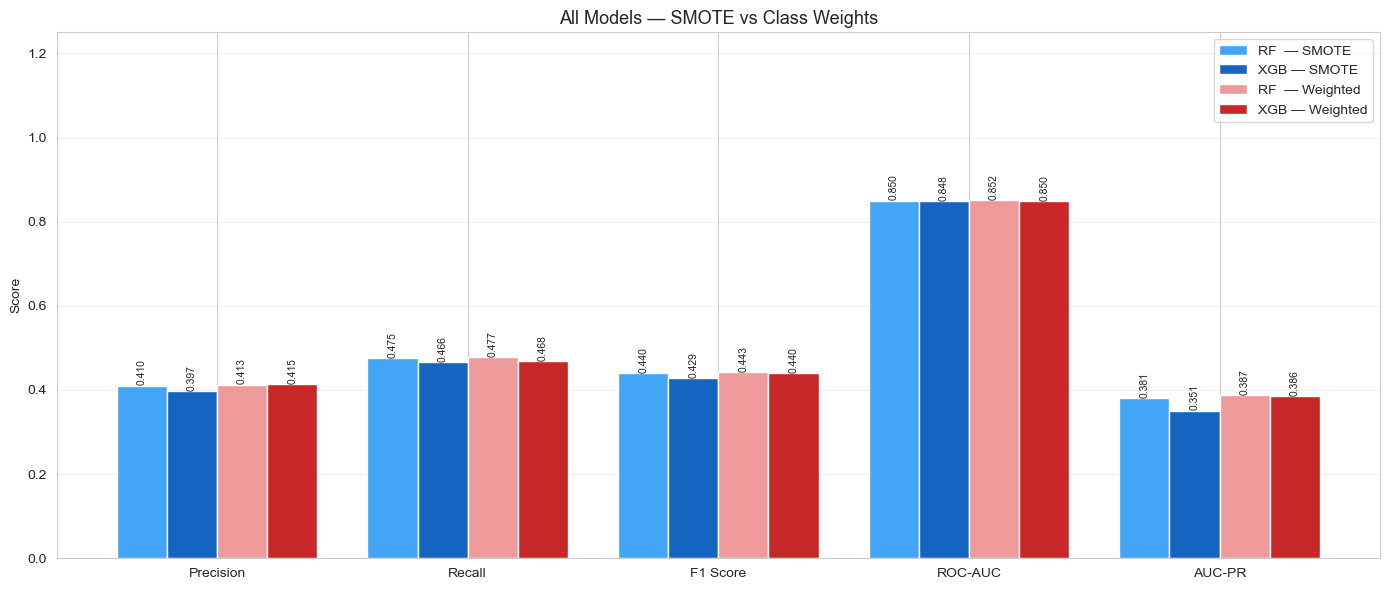

In [44]:
metrics_to_plot = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'AUC-PR']
x     = np.arange(len(metrics_to_plot))
width = 0.2
colors_map = {
    'RF  — SMOTE'   : '#42A5F5',
    'XGB — SMOTE'   : '#1565C0',
    'RF  — Weighted': '#EF9A9A',
    'XGB — Weighted': '#C62828',
}

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, row) in enumerate(all_results.iterrows()):
    bars = ax.bar(x + i * width, row[metrics_to_plot],
                  width, label=model_name,
                  color=list(colors_map.values())[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7.5, rotation=90)

ax.set_title('All Models — SMOTE vs Class Weights', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Score')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150)
plt.show()

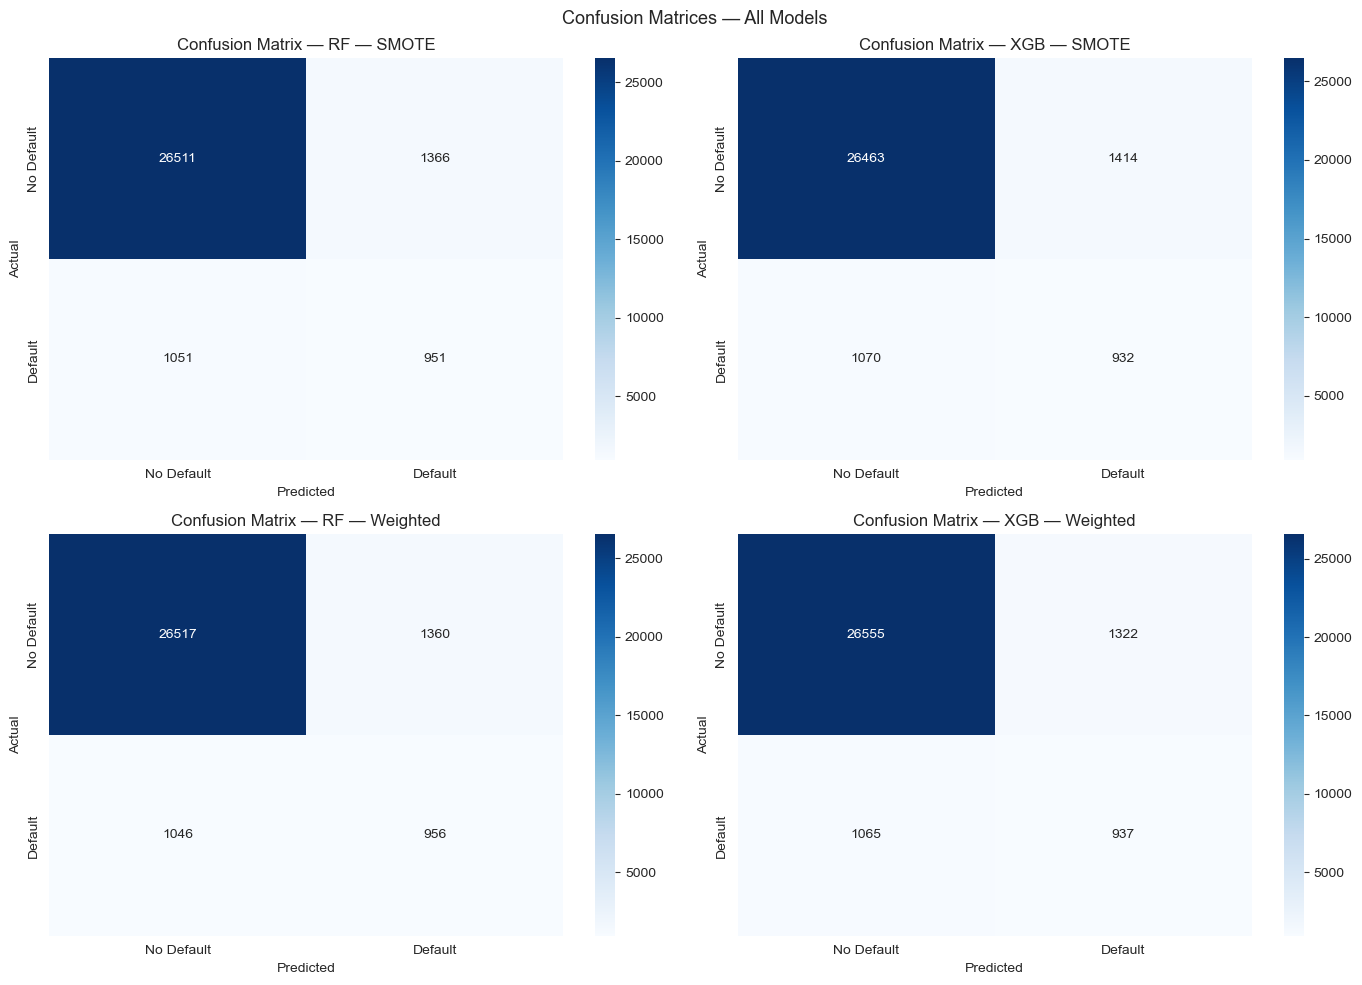

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_configs = [
    ('RF — SMOTE',    rf_smote_preds),
    ('XGB — SMOTE',   xgb_smote_preds),
    ('RF — Weighted', rf_w_preds),
    ('XGB — Weighted',xgb_w_preds),
]

for ax, (name, preds) in zip(axes, model_configs):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150)
plt.show()

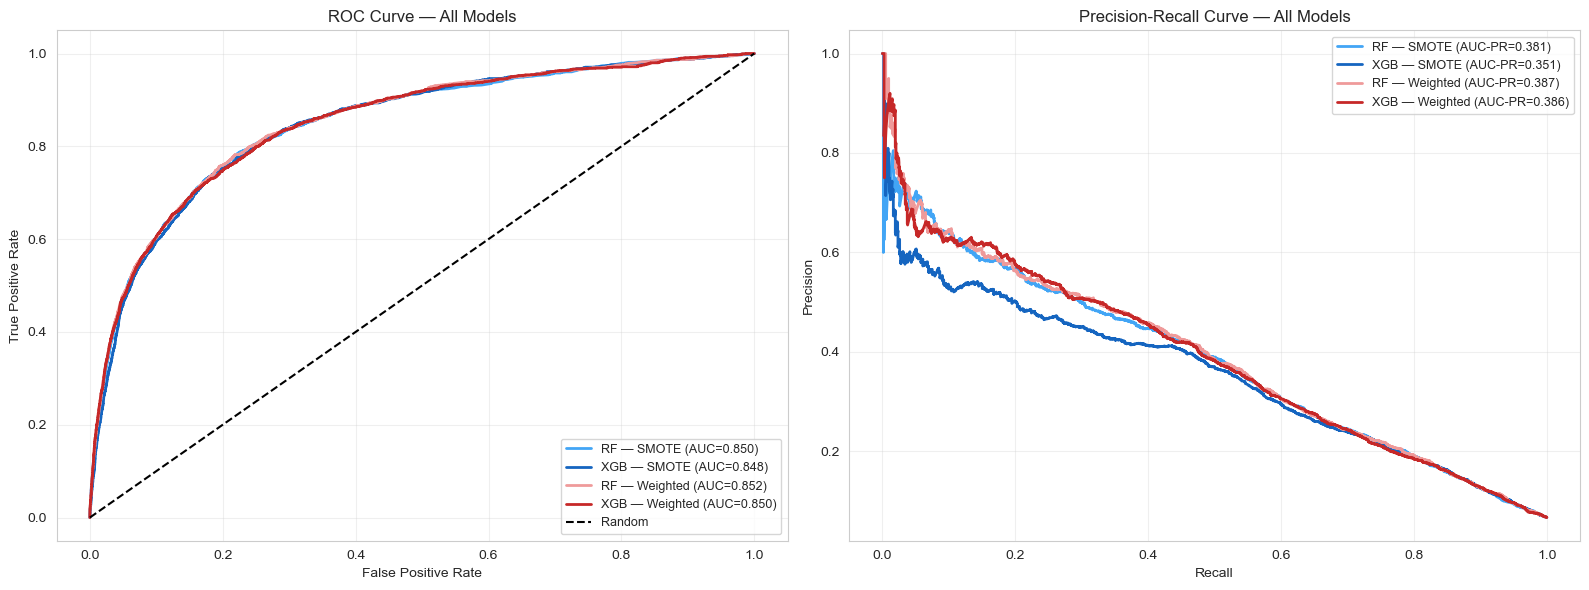

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

roc_configs = [
    ('RF — SMOTE',    rf_smote_probs,  '#42A5F5'),
    ('XGB — SMOTE',   xgb_smote_probs, '#1565C0'),
    ('RF — Weighted', rf_w_probs,      '#EF9A9A'),
    ('XGB — Weighted',xgb_w_probs,     '#C62828'),
]

for name, probs, color in roc_configs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val     = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title('ROC Curve — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

pr_configs = [
    ('RF — SMOTE',    rf_smote_probs,  rf_smote_thr,  '#42A5F5'),
    ('XGB — SMOTE',   xgb_smote_probs, xgb_smote_thr, '#1565C0'),
    ('RF — Weighted', rf_w_probs,      rf_w_thr,       '#EF9A9A'),
    ('XGB — Weighted',xgb_w_probs,     xgb_w_thr,      '#C62828'),
]

for name, probs, thr, color in pr_configs:
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec_arr, prec_arr, label=f'{name} (AUC-PR={ap:.3f})', color=color, linewidth=2)

axes[1].set_title('Precision-Recall Curve — All Models')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_all_models.png', dpi=150)
plt.show()

---
# Best Model Selection & Save

The best model across both approaches is selected by **AUC-PR**.  
All artifacts needed for prediction are saved to `model_artifacts/`.

In [47]:
best_model_name = all_results['AUC-PR'].idxmax()
best_row        = all_results.loc[best_model_name]

model_map = {
    'RF  — SMOTE'   : (rf_smote,    rf_smote_thr),
    'XGB — SMOTE'   : (xgb_smote,   xgb_smote_thr),
    'RF  — Weighted': (rf_weighted,  rf_w_thr),
    'XGB — Weighted': (xgb_weighted, xgb_w_thr),
}

best_model, best_threshold = model_map[best_model_name]

print('=== Best Model Selection (by AUC-PR) ===')
print(all_results[['Precision', 'Recall', 'F1 Score', 'AUC-PR']].to_string())
print(f'\n Best Model : {best_model_name}')
print(f'   AUC-PR     : {best_row["AUC-PR"]:.4f}')
print(f'   F1 Score   : {best_row["F1 Score"]:.4f}')
print(f'   Threshold  : {best_threshold:.4f}')

os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(best_model,     'model_artifacts/best_model.pkl')
joblib.dump(best_threshold, 'model_artifacts/best_threshold.pkl')
joblib.dump(FINAL_FEATURES, 'model_artifacts/feature_columns.pkl')

model_info = {
    'model_name'     : best_model_name,
    'threshold'      : best_threshold,
    'feature_columns': FINAL_FEATURES,
    'metrics': {
        'precision': best_row['Precision'],
        'recall'   : best_row['Recall'],
        'f1_score' : best_row['F1 Score'],
        'roc_auc'  : best_row['ROC-AUC'],
        'auc_pr'   : best_row['AUC-PR'],
    }
}
joblib.dump(model_info, 'model_artifacts/model_info.pkl')

print('\nArtifacts saved:')
print('  model_artifacts/best_model.pkl')
print('  model_artifacts/best_threshold.pkl')
print('  model_artifacts/feature_columns.pkl')
print('  model_artifacts/model_info.pkl')

=== Best Model Selection (by AUC-PR) ===
                Precision  Recall  F1 Score  AUC-PR
Model                                              
RF  — SMOTE        0.4104  0.4750    0.4404  0.3810
XGB — SMOTE        0.3973  0.4655    0.4287  0.3510
RF  — Weighted     0.4128  0.4775    0.4428  0.3874
XGB — Weighted     0.4148  0.4680    0.4398  0.3855

 Best Model : RF  — Weighted
   AUC-PR     : 0.3874
   F1 Score   : 0.4428
   Threshold  : 0.7982

Artifacts saved:
  model_artifacts/best_model.pkl
  model_artifacts/best_threshold.pkl
  model_artifacts/feature_columns.pkl
  model_artifacts/model_info.pkl


In [48]:
loaded_model     = joblib.load('model_artifacts/best_model.pkl')
loaded_threshold = joblib.load('model_artifacts/best_threshold.pkl')
loaded_features  = joblib.load('model_artifacts/feature_columns.pkl')
loaded_info      = joblib.load('model_artifacts/model_info.pkl')

print('=== Loaded Model Verification ===')
print(f'Model     : {loaded_info["model_name"]}')
print(f'Threshold : {loaded_info["threshold"]:.4f}')
print(f'Features  : {loaded_info["feature_columns"]}')
print(f'\nMetrics:')
for k, v in loaded_info['metrics'].items():
    print(f'  {k:12s}: {v:.4f}')

sample       = X_test.iloc[:5]
sample_probs = loaded_model.predict_proba(sample)[:, 1]
sample_preds = (sample_probs >= loaded_threshold).astype(int)

sample_out = sample.copy()
sample_out['Default_Probability'] = sample_probs.round(4)
sample_out['Prediction']          = sample_preds
sample_out['Label']               = sample_out['Prediction'].map({0: 'No Default', 1: 'Default'})

print('\n=== Sample Predictions ===')
print(sample_out[['Default_Probability', 'Label']].to_string())
print('\nModel is ready for prediction.')

=== Loaded Model Verification ===
Model     : RF  — Weighted
Threshold : 0.7982
Features  : ['Late30to59Days', 'TotalLatePayments', 'Age', 'RevolvingUtilizationRate', 'CreditRiskScore', 'AgeGroup_encoded', 'Late60to89Days', 'Times90DaysLate']

Metrics:
  precision   : 0.4128
  recall      : 0.4775
  f1_score    : 0.4428
  roc_auc     : 0.8518
  auc_pr      : 0.3874

=== Sample Predictions ===
        Default_Probability       Label
137020               0.0794  No Default
49339                0.7832  No Default
130878               0.0797  No Default
96834                0.2987  No Default
12756                0.1789  No Default

Model is ready for prediction.


In [49]:
gui_snippet = '''
import joblib
import pandas as pd

model     = joblib.load('model_artifacts/best_model.pkl')
threshold = joblib.load('model_artifacts/best_threshold.pkl')
features  = joblib.load('model_artifacts/feature_columns.pkl')

def predict_default(input_dict):
    df_input = pd.DataFrame([input_dict])[features]
    prob     = model.predict_proba(df_input)[0][1]
    pred     = int(prob >= threshold)
    return {
        'probability': round(prob, 4),
        'prediction' : pred,
        'label'      : 'Default' if pred == 1 else 'No Default'
    }
'''
print('=== Prediction Integration Snippet ===')
print(gui_snippet)

=== Prediction Integration Snippet ===

import joblib
import pandas as pd

model     = joblib.load('model_artifacts/best_model.pkl')
threshold = joblib.load('model_artifacts/best_threshold.pkl')
features  = joblib.load('model_artifacts/feature_columns.pkl')

def predict_default(input_dict):
    df_input = pd.DataFrame([input_dict])[features]
    prob     = model.predict_proba(df_input)[0][1]
    pred     = int(prob >= threshold)
    return {
        'probability': round(prob, 4),
        'prediction' : pred,
        'label'      : 'Default' if pred == 1 else 'No Default'
    }



---
# Step 6 — Data Visualization (Bonus)

Visualizations organized into four sections:
1. Class imbalance — before and after SMOTE
2. Model performance — confusion matrices, ROC curve, Precision-Recall curve
3. Feature insights — distributions, correlations, feature importance
4. Business insights — default rates by age group and income bracket

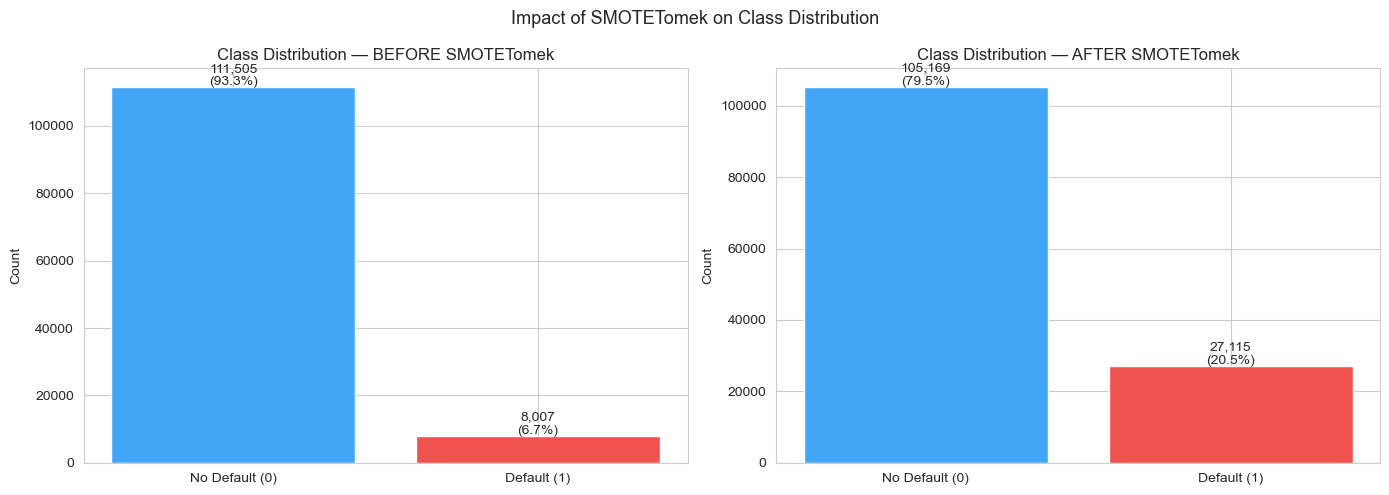

In [50]:
before_counts_viz = [int(y_train.value_counts()[0]), int(y_train.value_counts()[1])]
after_counts_viz  = [int(pd.Series(y_train_smote).value_counts()[0]),
                     int(pd.Series(y_train_smote).value_counts()[1])]
labels     = ['No Default (0)', 'Default (1)']
bar_colors = ['#42A5F5', '#EF5350']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars0 = axes[0].bar(labels, before_counts_viz, color=bar_colors, edgecolor='white')
for bar, val in zip(bars0, before_counts_viz):
    pct = val / sum(before_counts_viz) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class Distribution — BEFORE SMOTETomek')
axes[0].set_ylabel('Count')

bars1 = axes[1].bar(labels, after_counts_viz, color=bar_colors, edgecolor='white')
for bar, val in zip(bars1, after_counts_viz):
    pct = val / sum(after_counts_viz) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)
axes[1].set_title('Class Distribution — AFTER SMOTETomek')
axes[1].set_ylabel('Count')

plt.suptitle('Impact of SMOTETomek on Class Distribution', fontsize=13)
plt.tight_layout()
plt.show()

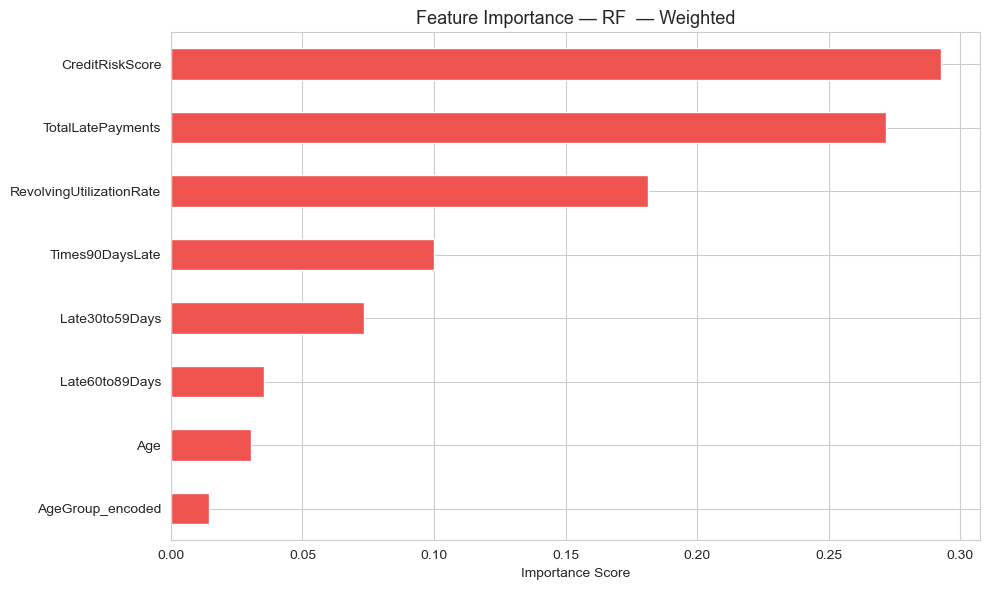

In [51]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(
        best_model.feature_importances_, index=FINAL_FEATURES
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp.plot(kind='barh', ax=ax, color='#EF5350', edgecolor='white')
    ax.set_title(f'Feature Importance — {best_model_name}', fontsize=13)
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

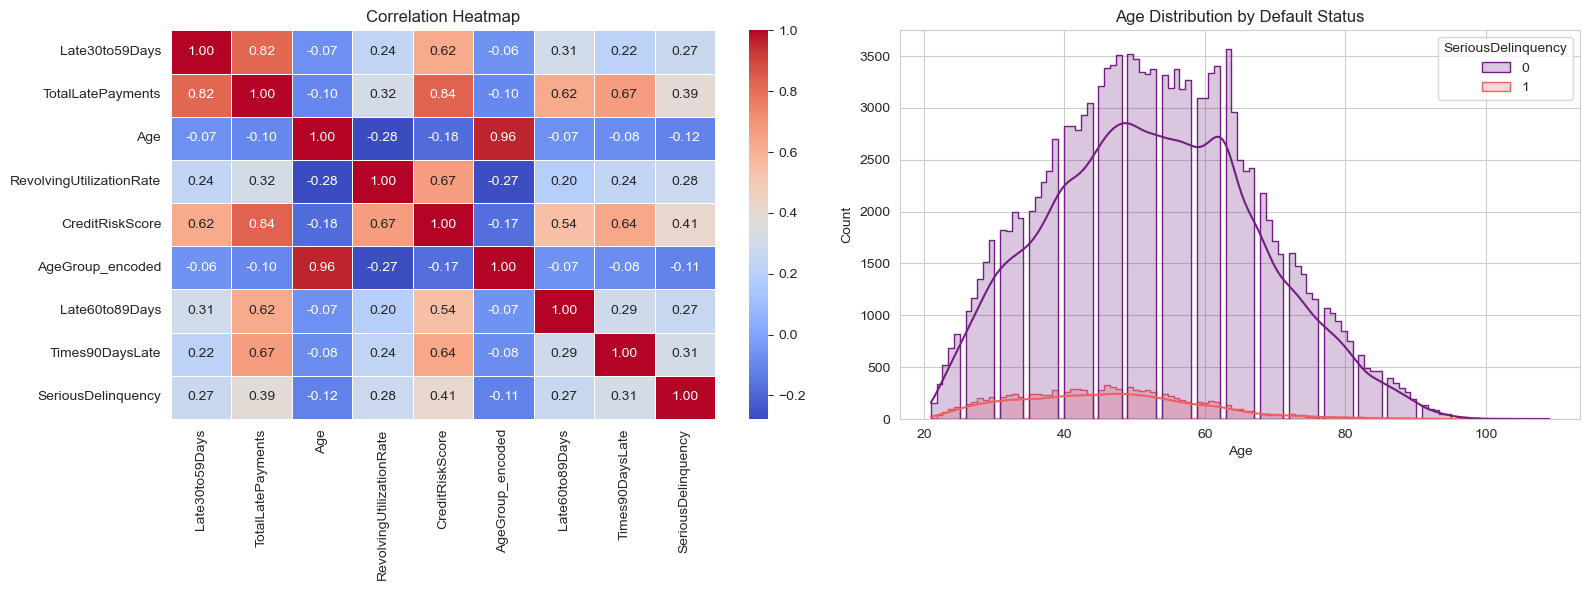

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df[FINAL_FEATURES + [TARGET_COL]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

sns.histplot(data=df, x='Age', hue='SeriousDelinquency',
             kde=True, element='step', palette='magma', ax=axes[1])
axes[1].set_title('Age Distribution by Default Status')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

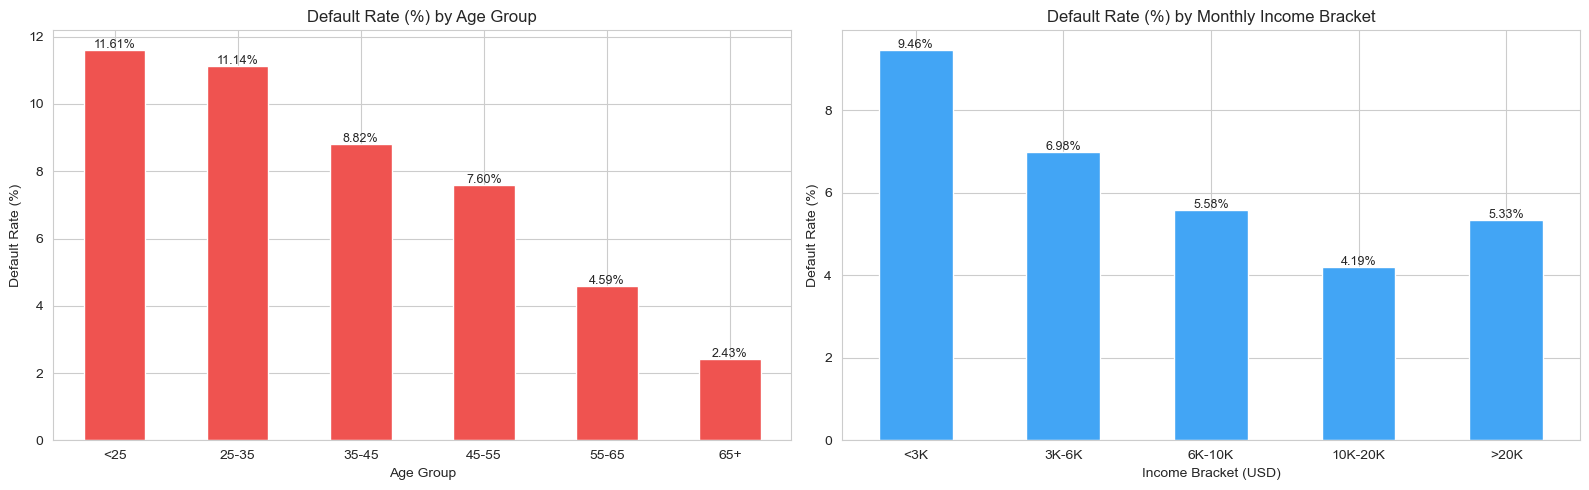

In [53]:
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

df['IncomeBracket'] = pd.cut(df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000, float('inf')],
    labels=['<3K', '3K-6K', '6K-10K', '10K-20K', '>20K'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

age_default = df.groupby('AgeGroup')['SeriousDelinquency'].mean() * 100
age_default.plot(kind='bar', ax=axes[0], color='#EF5350', edgecolor='white')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.05),
                     ha='center', fontsize=9)
axes[0].set_title('Default Rate (%) by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

income_default = df.groupby('IncomeBracket')['SeriousDelinquency'].mean() * 100
income_default.plot(kind='bar', ax=axes[1], color='#42A5F5', edgecolor='white')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.05),
                     ha='center', fontsize=9)
axes[1].set_title('Default Rate (%) by Monthly Income Bracket')
axes[1].set_xlabel('Income Bracket (USD)')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

df.drop(columns=['AgeGroup', 'IncomeBracket'], inplace=True)